In [10]:
import xarray as xr
import numpy as np
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cmcrameri import cm
import cmocean as cmo

In [11]:
ds_insitu = xr.open_dataset('fresh_data/data_for_LSTM_filled.nc', decode_times=True)

ds_glorys = xr.open_mfdataset('/home/nico/SACO/FRESH-CARE/Data_reanalysis/GLORYS/*.nc')
ds_glorys

<xarray.Dataset> Size: 335GB
Dimensions:    (time: 156, latitude: 601, longitude: 4320, depth: 50)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2010-01-16T12:00:00 ... 2022-12-16T1...
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9
  * latitude   (latitude) float32 2kB 40.0 40.08 40.17 ... 89.83 89.92 90.0
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
Data variables:
    mlotst     (time, latitude, longitude) float32 2GB dask.array<chunksize=(1, 60, 4320), meta=np.ndarray>
    zos        (time, latitude, longitude) float32 2GB dask.array<chunksize=(1, 60, 4320), meta=np.ndarray>
    bottomT    (time, latitude, longitude) float32 2GB dask.array<chunksize=(1, 60, 4320), meta=np.ndarray>
    sithick    (time, latitude, longitude) float32 2GB dask.array<chunksize=(1, 60, 4320), meta=np.ndarray>
    siconc     (time, latitude, longitude) float32 2GB dask.array<chunksize=(1, 60, 4320), meta=np.ndarray>
    usi        (time, latitude, longitude) float32 2GB dask.array<chunksize=(1, 60, 4320), meta=np.ndarray>
    vsi        (time, latitude, longitude) float32 2GB dask.array<chunksize=(1, 60, 4320), meta=np.ndarray>
    thetao     (time, depth, latitude, longitude) float32 81GB dask.array<chunksize=(1, 1, 60, 4320), meta=np.ndarray>
    so         (time, depth, latitude, longitude) float32 81GB dask.array<chunksize=(1, 1, 60, 4320), meta=np.ndarray>
    uo         (time, depth, latitude, longitude) float32 81GB dask.array<chunksize=(1, 1, 60, 4320), meta=np.ndarray>
    vo         (time, depth, latitude, longitude) float32 81GB dask.array<chunksize=(1, 1, 60, 4320), meta=np.ndarray>
Attributes: (12/17)
    CDI:                           Climate Data Interface version 2.3.0 (http...
    Conventions:                   CF-1.6
    source:                        MERCATOR GLORYS12V1
    institution:                   Mercator Ocean
    title:                         Monthly mean fields for product GLOBAL_REA...
    references:                    http://marine.copernicus.eu
    ...                            ...
    product:                       GLOBAL_REANALYSIS_001_030
    dataset:                       global-reanalysis-001-030-monthly
    product_user_manual:           http://marine.copernicus.eu/documents/PUM/...
    quality_information_document:  http://marine.copernicus.eu/documents/QUID...
    history:                       Fri Jul 19 12:18:18 2024: cdo -O -s -sello...
    CDO:                           Climate Data Operators version 2.3.0 (http...

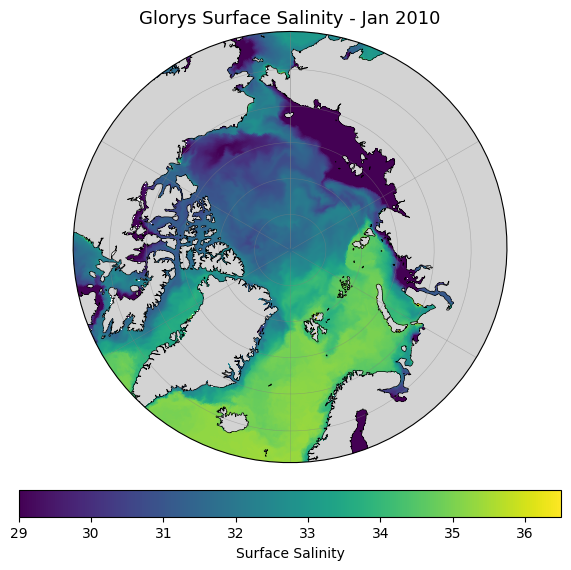

In [16]:
values = ds_glorys['so'].isel(depth=0, time=0).values

# Extract lat/lon
lats = ds_glorys['latitude'].values
lons = ds_glorys['longitude'].values

# Create figure and Arctic projection
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Set extent: Northern Hemisphere only
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(
cfeature.LAND
, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=False, linewidth=0.4, color='gray', alpha=0.5)

# Add circle boundary (matching your existing functions)
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# Use pcolormesh for gridded data instead of scatter
sc = ax.pcolormesh(
    lons, lats, values,
    cmap='viridis', 
    transform=ccrs.PlateCarree(),
    vmin=29, vmax=36.5,
    shading='auto'
)

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Surface Salinity')
plt.title("Glorys Surface Salinity - Jan 2010", fontsize=13)
plt.savefig('plots/S_glorys_surface.png', dpi=350)
plt.show()

In [ ]:
# Add circle boundary (matching your existing functions)
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

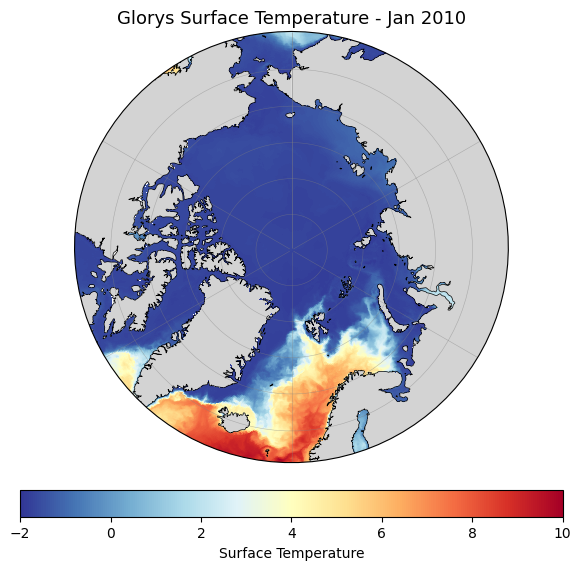

In [23]:
values = ds_glorys['thetao'].isel(depth=0, time=0).values

# Extract lat/lon
lats = ds_glorys['latitude'].values
lons = ds_glorys['longitude'].values

# Create figure and Arctic projection
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Set extent: Northern Hemisphere only
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(
cfeature.LAND
, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=False, linewidth=0.4, color='gray', alpha=0.5)

# Add circle boundary (matching your existing functions)
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# Use pcolormesh for gridded data instead of scatter
sc = ax.pcolormesh(
    lons, lats, values,
    cmap='RdYlBu_r', 
    transform=ccrs.PlateCarree(),
    vmin=-2, vmax=10,
    shading='auto'
)

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Surface Temperature')
plt.title("Glorys Surface Temperature - Jan 2010", fontsize=13)
plt.savefig('plots/T_glorys_surface.png', dpi=350)
plt.show()